In [ ]:
import re
import pdfplumber
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
pdf_path = "../Data/LEGEND data.pdf"
num_re = re.compile(r"-?\d+(?:\.\d+)?")

rows = []
buffer = []

N = 6  # date, spacecraft, rocket bodies, mission-related, fragmentation, total


In [ ]:
with pdfplumber.open(pdf_path) as pdf:
    for page in pdf.pages:
        text = page.extract_text() or ""
        for line in text.splitlines():
            line = line.strip()
            if not line:
                continue

            nums = num_re.findall(line)
            if not nums:
                continue

            first = nums[0]
            is_new_row = bool(re.match(r"^\d{4}\.\d{2}$", first))

            if is_new_row:
                if len(buffer) >= N:
                    rows.append(buffer[:N])
                buffer = nums
            else:
                if buffer:
                    buffer += nums

In [4]:
# flush last
if len(buffer) >= N:
    rows.append(buffer[:N])

df = pd.DataFrame(
    rows,
    columns=["date", "spacecraft", "rocket_bodies", "mission_related", "fragmentation", "total"]
)

In [ ]:
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["date", "total"]).reset_index(drop=True)

In [6]:
print(df.head())
print(df.tail())

      date  spacecraft  rocket_bodies  mission_related  fragmentation  total
0  1957.00           0              0                0              0      0
1  1957.09           0              0                0              0      0
2  1957.16           0              0                0              0      0
3  1957.25           0              0                0              0      0
4  1957.33           0              0                0              0      0
        date  spacecraft  rocket_bodies  mission_related  fragmentation  total
788  2022.67        9779           2086             2034          12180  26079
789  2022.75        9989           2100             2018          12076  26183
790  2022.84       10005           2105             1988          12525  26623
791  2022.92       10142           2101             1976          12425  26644
792  2023.00       10380           2105             1974          12328  26787


In [7]:
df_hist = df
df_jam = pd.read_csv("jam_simulation_no_ADR_1970_start.csv")

In [8]:
df_hist = df_hist.rename(columns={"date": "year"})

df_hist_70_00 = df_hist[
    (df_hist["year"] >= 1970) &
    (df_hist["year"] <= 2000)
].reset_index(drop=True)

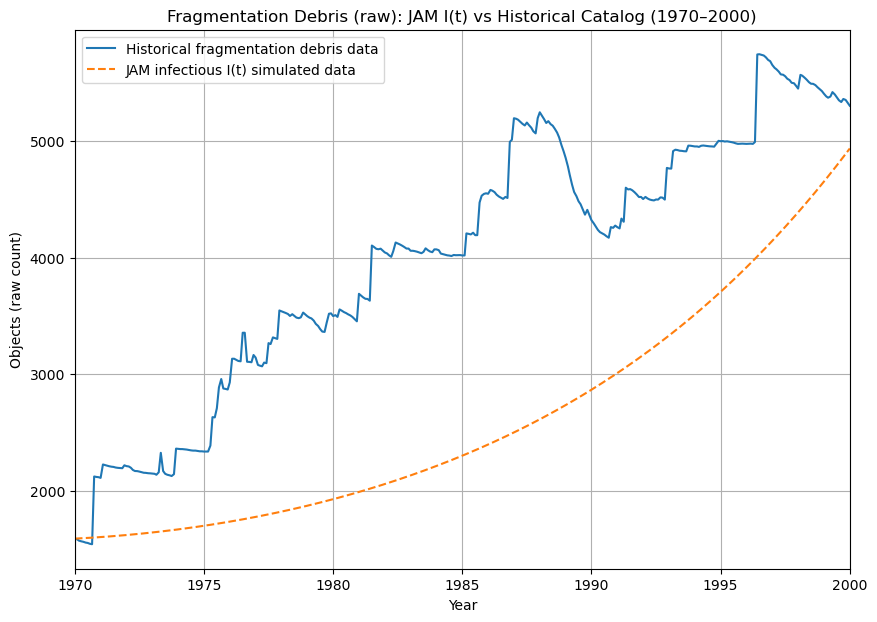

In [ ]:
plt.figure(figsize=(10,7))
plt.plot(df_hist_70_00["year"], df_hist_70_00["fragmentation"], label="Historical fragmentation debris data")
plt.plot(df_jam["year"], df_jam["I"], "--", label="JAM infectious I(t) simulated data")
plt.xlim(1970, 2000)
plt.xlabel("Year")
plt.ylabel("Objects (raw count)")
plt.title("Fragmentation Debris (raw): JAM I(t) vs Historical Catalog (1970–2000)")
plt.legend()
plt.grid(True)
plt.show()


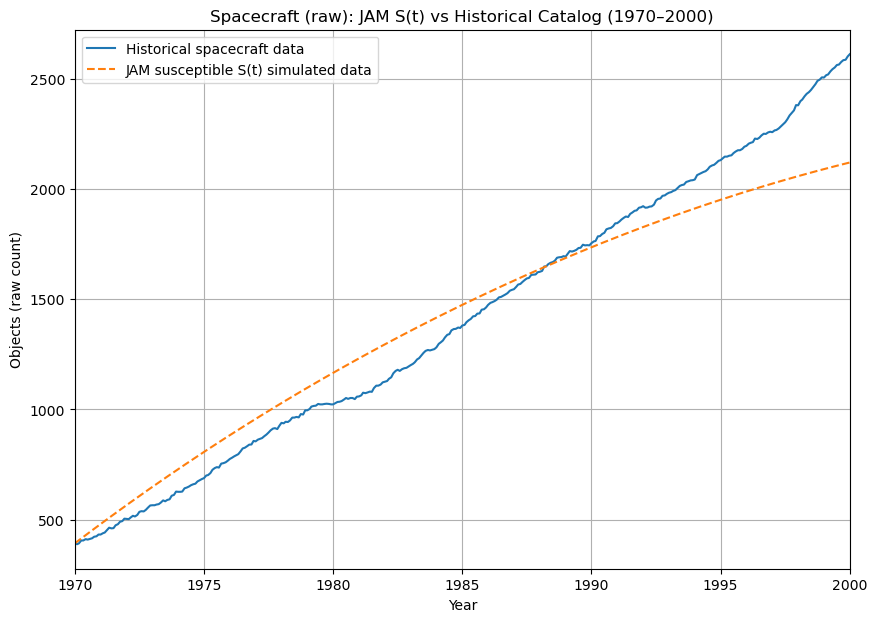

In [10]:
plt.figure(figsize=(10,7))
plt.plot(df_hist_70_00["year"], df_hist_70_00["spacecraft"], label="Historical spacecraft data")
plt.plot(df_jam["year"], df_jam["S"], "--", label="JAM susceptible S(t) simulated data")
plt.xlim(1970, 2000)
plt.xlabel("Year")
plt.ylabel("Objects (raw count)")
plt.title("Spacecraft (raw): JAM S(t) vs Historical Catalog (1970–2000)")
plt.legend()
plt.grid(True)
plt.show()